# Energy-bench — Single-notebook prototype
*Prototyping: synthetic data → ARIMA / RF / LSTM baselines → battery sim → economic metrics (PES/PEC/GR).*


In [2]:
# Cell 2: imports & environment check
import sys, os, warnings
print("python", sys.version.split()[0])
import numpy as np, pandas as pd
import sklearn, statsmodels, tensorflow as tf
print("pandas", pd.__version__, "numpy", np.__version__, "sklearn", sklearn.__version__, "statsmodels", statsmodels.__version__, "tf", tf.__version__)
warnings.filterwarnings("ignore")


python 3.11.11
pandas 2.2.3 numpy 2.1.3 sklearn 1.7.1 statsmodels 0.14.5 tf 2.19.0


In [3]:
# Cell 3: synthetic data generator
from datetime import datetime
def generate_synthetic(start='2020-01-01', days=180, freq='H', seed=42):
    np.random.seed(seed)
    idx = pd.date_range(start=start, periods=24*days, freq=freq)
    t = np.arange(len(idx))
    day_of_year = idx.dayofyear.values
    # solar
    solar_diurnal = np.maximum(0, np.sin((t % 24) / 24 * 2*np.pi))
    solar_seasonal = 0.5 + 0.5*np.sin(2*np.pi*(day_of_year/365.0))
    solar = 800 * solar_diurnal * solar_seasonal + np.random.normal(0, 30, size=len(idx))
    # wind
    wind_base = 6 + 2*np.sin(2*np.pi*(t/24)/3)
    wind = np.maximum(0, wind_base + np.random.normal(0, 2.5, size=len(idx)))
    # demand
    demand = 50 + 20*np.sin(((t % 24)-7)/24 * 2*np.pi) + 10*np.sin(2*np.pi*(day_of_year/365.0))
    demand = np.maximum(0, demand + np.random.normal(0, 5, size=len(idx)))
    df = pd.DataFrame({'solar_irradiance': solar, 'wind_speed': wind, 'demand': demand}, index=idx)
    df.index.name = 'timestamp'
    return df

df = generate_synthetic(days=120)
df.head()


,solar_irradiance,wind_speed,demand
timestamp,,,
2020-01-01 00:00:00,14.901425,0.404422,31.000770
2020-01-01 01:00:00,101.161747,0.872561,32.755356
2020-01-01 02:00:00,222.873327,4.830133,25.946987
2020-01-01 03:00:00,333.402281,7.661855,25.827541
2020-01-01 04:00:00,345.348442,0.000000,36.566038


In [4]:
# Cell 4: split & features
def time_split(df, train_frac=0.7, val_frac=0.15):
    n = len(df); ntrain = int(n*train_frac); nval = int(n*val_frac)
    return df.iloc[:ntrain], df.iloc[ntrain:ntrain+nval], df.iloc[ntrain+nval:]

train, val, test = time_split(df)
print("train/val/test sizes:", len(train), len(val), len(test))

# simple lag features for sklearn baselines
def make_window_features(df, lookback=24):
    X, y, idx = [], [], []
    arr = df[['demand','solar_irradiance','wind_speed']].values
    for i in range(lookback, len(df)):
        win = arr[i-lookback:i].flatten()
        meta = [df.index[i].hour, df.index[i].dayofyear]
        X.append(np.hstack([win, meta]))
        y.append(arr[i,0])
        idx.append(df.index[i])
    X = np.array(X); y = np.array(y)
    return pd.DataFrame(X, index=idx), pd.Series(y, index=idx)

X_all, y_all = make_window_features(df, lookback=24)
# split windows aligned with time_split
ntrain = len(train) - 24
nval = len(val)
X_train, y_train = X_all.iloc[:ntrain], y_all.iloc[:ntrain]
X_test, y_test = X_all.iloc[ntrain:ntrain+len(test)], y_all.iloc[ntrain:ntrain+len(test)]
print("windowed shapes:", X_train.shape, X_test.shape)


train/val/test sizes: 2015 432 433
windowed shapes: (1991, 74) (433, 74)


In [5]:
# Cell 5: Rolling ARIMA forecast for demand (simple)
from statsmodels.tsa.arima.model import ARIMA
def rolling_arima(series, train_size, horizon=24, order=(5,1,0)):
    preds = []
    idxs = []
    for start in range(train_size, len(series)-horizon+1, horizon):
        train_series = series.iloc[:start]
        try:
            m = ARIMA(train_series, order=order).fit()
            fc = m.forecast(steps=horizon)
        except Exception:
            fc = pd.Series(np.repeat(train_series.mean(), horizon), index=series.index[start:start+horizon])
        preds.extend(fc)
        idxs.extend(series.index[start:start+horizon])
    return pd.Series(preds, index=idxs)

demand_series = df['demand']
train_size = len(train)
arima_pred = rolling_arima(demand_series, train_size=train_size, horizon=24)
# align to test slice
arima_pred = arima_pred.reindex(y_test.index).fillna(method='ffill')
print("ARIMA preds:", arima_pred.shape)


ARIMA preds: (433,)


In [6]:
# Cell 6: RandomForest & GradientBoosting baselines
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train); gb.fit(X_train, y_train)
rf_pred = pd.Series(rf.predict(X_test), index=y_test.index)
gb_pred = pd.Series(gb.predict(X_test), index=y_test.index)
print("RF/GB done.")


RF/GB done.


In [7]:
# Cell 7: LSTM baseline (minimal training, small epochs)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

def make_seq(df, lookback=24):
    arr = df[['demand','solar_irradiance','wind_speed']].values
    X,y,idx = [],[],[]
    for i in range(lookback,len(df)):
        X.append(arr[i-lookback:i])
        y.append(arr[i,0])
        idx.append(df.index[i])
    return np.array(X), np.array(y), idx

Xseq, yseq, idxs = make_seq(df, lookback=24)
# split aligned with earlier split
X_train_seq = Xseq[:ntrain]; y_train_seq = yseq[:ntrain]
X_test_seq = Xseq[ntrain:ntrain+len(test)]; y_test_seq = yseq[ntrain:ntrain+len(test)]
# build model
model = Sequential([LSTM(64, input_shape=(24,3)), Dense(32, activation='relu'), Dense(1)])
model.compile(optimizer=Adam(1e-3), loss='mse')
# small training for demo
model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=64, validation_split=0.1, verbose=0)
lstm_pred = pd.Series(model.predict(X_test_seq).flatten(), index=y_test.index)
print("LSTM done.")


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step
LSTM done.


In [8]:
# Cell 8: battery model & simple rule-based controller
class Battery:
    def __init__(self, cap_kwh=100.0, soc0=0.5, pmax=50.0, eff=0.95):
        self.cap=cap_kwh; self.soc=soc0*cap_kwh; self.pmax=pmax; self.eff=eff
    def step(self, p_kw, hours=1.0):
        p_kw = np.clip(p_kw, -self.pmax, self.pmax)
        if p_kw>=0: self.soc += p_kw*hours*self.eff
        else: self.soc += p_kw*hours/self.eff
        self.soc = np.clip(self.soc, 0, self.cap)
        return self.soc/self.cap

def rule_controller(gen, dem, battery:Battery):
    actions=[]; socs=[]
    for g,d in zip(gen, dem):
        surplus = g - d
        if surplus > 1.0:
            a = min(surplus, battery.pmax)
        elif surplus < -1.0:
            a = max(surplus, -battery.pmax)
        else:
            a = 0.0
        battery.step(a)
        actions.append(a); socs.append(battery.soc)
    return np.array(actions), np.array(socs)

# use solar irradiance scaled as generation proxy for demo
gen_test = df['solar_irradiance'].reindex(y_test.index).fillna(0).values/10.0
demand_test = y_test.values
bat = Battery()
actions, socs = rule_controller(gen_test, demand_test, bat)


In [9]:
# Cell 9: metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
def mae(a,b): return mean_absolute_error(a,b)
def rmse(a,b): return np.sqrt(mean_squared_error(a,b))
def pinball(y, yhat, q=0.5): 
    e = y - yhat
    return np.mean(np.maximum(q*e, (q-1)*e))

def compute_pes(gen, dem): return np.sum(np.maximum(0, gen-dem))
def compute_pec(imported, tariff=0.1): return np.sum(imported)*tariff
def compute_gr(sold, price=0.08): return np.sum(sold)*price

results = {}
results['arima_mae'] = mae(y_test, arima_pred)
results['rf_mae'] = mae(y_test, rf_pred)
results['gb_mae'] = mae(y_test, gb_pred)
results['lstm_mae'] = mae(y_test, lstm_pred)
# economics using gen_test aligned to y_test
results['pes_MWh'] = compute_pes(gen_test, demand_test)
imported = np.maximum(0, demand_test - gen_test)  # simplified
sold = np.maximum(0, gen_test - demand_test)
results['pec_$'] = compute_pec(imported)
results['gr_$'] = compute_gr(sold)
results


{'arima_mae': 28.92241455819196,
 'rf_mae': 4.194377579432841,
 'gb_mae': 4.434490731404107,
 'lstm_mae': 19.829074663503533,
 'pes_MWh': np.float64(2025.4948461089114),
 'pec_$': np.float64(1709.8576077646962),
 'gr_$': np.float64(162.0395876887129)}

RESULTS SUMMARY
arima_mae   : 28.9224
rf_mae      : 4.1944
gb_mae      : 4.4345
lstm_mae    : 19.8291
pes_MWh     : 2025.4948
pec_$       : 1709.8576
gr_$        : 162.0396


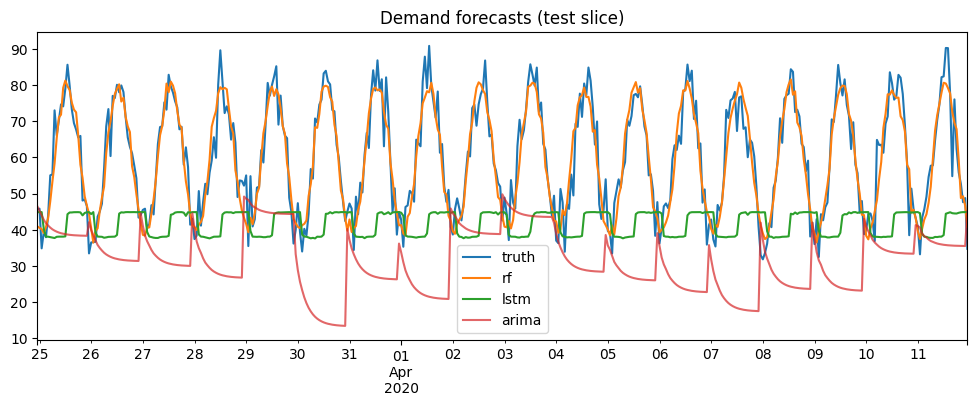

In [10]:
# Cell 10: display and quick plots
print("RESULTS SUMMARY")
for k,v in results.items():
    print(f"{k:12s}: {v:.4f}" if isinstance(v,(int,float,np.floating)) else f"{k}: {v}")

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
y_test.plot(label='truth'); rf_pred.plot(label='rf'); lstm_pred.plot(label='lstm'); arima_pred.plot(label='arima', alpha=0.7)
plt.legend(); plt.title("Demand forecasts (test slice)")
plt.show()


In [11]:
# Cell 11: save results & predictions for artifact
out_dir = "results_demo"
os.makedirs(out_dir, exist_ok=True)
pd.DataFrame({'truth':y_test, 'rf':rf_pred, 'gb':gb_pred, 'lstm':lstm_pred, 'arima':arima_pred}).to_csv(os.path.join(out_dir,'predictions.csv'))
pd.Series(results).to_csv(os.path.join(out_dir,'metrics.csv'))
print("Saved results to", out_dir)


Saved results to results_demo


# PROB TRANSFORMER PIPELINES

In [12]:
# A: settings + quantile loss
import tensorflow as tf
from tensorflow.keras.layers import Dense, LayerNormalization, Dropout, MultiHeadAttention
from tensorflow.keras import Model, Input
import numpy as np

LOOKBACK = 48      # input window (hours)
HORIZON  = 24      # forecast horizon (hours)
FEATURES = 3       # demand, solar, wind
D_MODEL  = 64
N_HEADS  = 4
ENC_LAYERS = 2
QUANTILES = [0.1, 0.5, 0.9]  # output quantiles

def quantile_loss(q, y, f):
    e = (y - f)
    return tf.reduce_mean(tf.maximum(q*e, (q-1)*e))

def multi_quantile_loss(y_true, y_pred):
    # y_pred shape: (batch, horizon, n_quantiles)
    losses = []
    for i,q in enumerate(QUANTILES):
        losses.append(quantile_loss(q, y_true, y_pred[..., i]))
    return tf.add_n(losses) / len(losses)


In [13]:
# B: Positional encoding + small transformer encoder block
import tensorflow as tf

def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2*(i//2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    # apply sin to even indices; cos to odd indices
    pos_encoding = np.zeros((seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(pos_encoding, dtype=tf.float32)

class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff=128, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads)
        self.ffn = tf.keras.Sequential([Dense(dff, activation='relu'), Dense(d_model)])
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.dropout = Dropout(dropout)
    def call(self, x, training=False):
        attn = self.mha(x, x, attention_mask=None)  # self-attention
        out1 = self.norm1(x + self.dropout(attn, training=training))
        ffn_out = self.ffn(out1)
        out2 = self.norm2(out1 + self.dropout(ffn_out, training=training))
        return out2


In [14]:
# C: Build model (encoder -> pooled -> repeat -> LSTM decoder -> quantiles)
from tensorflow.keras.layers import GlobalAveragePooling1D, RepeatVector, LSTM, TimeDistributed

def build_prob_transformer(lookback=LOOKBACK, features=FEATURES, d_model=D_MODEL,
                           n_heads=N_HEADS, n_layers=ENC_LAYERS, horizon=HORIZON, n_quantiles=len(QUANTILES)):
    inp = Input(shape=(lookback, features), name='past_obs')
    # project to d_model
    x = Dense(d_model)(inp)
    # add positional encoding
    pos = positional_encoding(lookback, d_model)
    x = x + pos
    # encoder stack
    for _ in range(n_layers):
        x = TransformerEncoderLayer(d_model, n_heads)(x)
    # compress/summary
    x = GlobalAveragePooling1D()(x)
    x = Dense(d_model, activation='relu')(x)
    # decoder: repeat then LSTM to produce horizon-length sequence
    x = RepeatVector(horizon)(x)
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.1)(x)
    out = TimeDistributed(Dense(n_quantiles))(x)  # outputs quantiles per horizon step
    model = Model(inp, out)
    model.compile(optimizer='adam', loss=multi_quantile_loss)
    return model

model_prob = build_prob_transformer()
model_prob.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ past_obs (InputLayer)                │ (None, 48, 3)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 48, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ add (Add)                            │ (None, 48, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_encoder_layer            │ (None, 48, 64)              │          33,472 │
│ (TransformerEncoderLayer)            │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_encoder_layer_1          │ (None, 48, 64)              │          33,472 │
│ (TransformerEncoderLayer)            │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 24, 128)             │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 24, 3)               │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 170,563 (666.26 KB)

 Trainable params: 170,563 (666.26 KB)

 Non-trainable params: 0 (0.00 B)

# Energy-bench — Integrated notebook (updated, fixed)
Prototype: synthetic data → ARIMA / RF / LSTM baselines → probabilistic Transformer (quantiles) → battery sim → economic metrics.


In [1]:
# Cell 2
import sys, os, warnings
print("python", sys.version.split()[0])
import numpy as np, pandas as pd
import sklearn, statsmodels, tensorflow as tf
print("pandas", pd.__version__, "numpy", np.__version__, "sklearn", sklearn.__version__, "statsmodels", statsmodels.__version__, "tf", tf.__version__)
warnings.filterwarnings("ignore")


python 3.11.11
pandas 2.2.3 numpy 2.1.3 sklearn 1.7.1 statsmodels 0.14.5 tf 2.19.0


In [2]:
# Cell 3
from datetime import datetime
def generate_synthetic(start='2020-01-01', days=180, freq='H', seed=42):
    np.random.seed(seed)
    idx = pd.date_range(start=start, periods=24*days, freq=freq)
    t = np.arange(len(idx))
    day_of_year = idx.dayofyear.values
    solar_diurnal = np.maximum(0, np.sin((t % 24) / 24 * 2*np.pi))
    solar_seasonal = 0.5 + 0.5*np.sin(2*np.pi*(day_of_year/365.0))
    solar = 800 * solar_diurnal * solar_seasonal + np.random.normal(0, 30, size=len(idx))
    wind_base = 6 + 2*np.sin(2*np.pi*(t/24)/3)
    wind = np.maximum(0, wind_base + np.random.normal(0, 2.5, size=len(idx)))
    demand = 50 + 20*np.sin(((t % 24)-7)/24 * 2*np.pi) + 10*np.sin(2*np.pi*(day_of_year/365.0))
    demand = np.maximum(0, demand + np.random.normal(0, 5, size=len(idx)))
    df = pd.DataFrame({'solar_irradiance': solar, 'wind_speed': wind, 'demand': demand}, index=idx)
    df.index.name = 'timestamp'
    return df

df = generate_synthetic(days=120)
df.head()


,solar_irradiance,wind_speed,demand
timestamp,,,
2020-01-01 00:00:00,14.901425,0.404422,31.000770
2020-01-01 01:00:00,101.161747,0.872561,32.755356
2020-01-01 02:00:00,222.873327,4.830133,25.946987
2020-01-01 03:00:00,333.402281,7.661855,25.827541
2020-01-01 04:00:00,345.348442,0.000000,36.566038


In [3]:
# Cell 4
def time_split(df, train_frac=0.7, val_frac=0.15):
    n = len(df); ntrain = int(n*train_frac); nval = int(n*val_frac)
    return df.iloc[:ntrain], df.iloc[ntrain:ntrain+nval], df.iloc[ntrain+nval:]

train, val, test = time_split(df)
print("train/val/test sizes:", len(train), len(val), len(test))

def make_window_features(df, lookback=24):
    X, y, idx = [], [], []
    arr = df[['demand','solar_irradiance','wind_speed']].values
    for i in range(lookback, len(df)):
        win = arr[i-lookback:i].flatten()
        meta = [df.index[i].hour, df.index[i].dayofyear]
        X.append(np.hstack([win, meta]))
        y.append(arr[i,0])
        idx.append(df.index[i])
    X = np.array(X); y = np.array(y)
    return pd.DataFrame(X, index=idx), pd.Series(y, index=idx)

X_all, y_all = make_window_features(df, lookback=24)
ntrain = len(train) - 24   # align for windows
X_train, y_train = X_all.iloc[:ntrain], y_all.iloc[:ntrain]
X_test, y_test = X_all.iloc[ntrain:ntrain+len(test)], y_all.iloc[ntrain:ntrain+len(test)]
print("windowed shapes:", X_train.shape, X_test.shape)


train/val/test sizes: 2015 432 433
windowed shapes: (1991, 74) (433, 74)


In [4]:
# Cell 5
from statsmodels.tsa.arima.model import ARIMA
def rolling_arima(series, train_size, horizon=24, order=(5,1,0)):
    preds = []; idxs = []
    for start in range(train_size, len(series)-horizon+1, horizon):
        train_series = series.iloc[:start]
        try:
            m = ARIMA(train_series, order=order).fit()
            fc = m.forecast(steps=horizon)
        except Exception:
            fc = pd.Series(np.repeat(train_series.mean(), horizon), index=series.index[start:start+horizon])
        preds.extend(fc)
        idxs.extend(series.index[start:start+horizon])
    return pd.Series(preds, index=idxs)

demand_series = df['demand']
train_size = len(train)
arima_pred_all = rolling_arima(demand_series, train_size=train_size, horizon=24)
# align arima preds to test indices used earlier (safe fill)
arima_pred = arima_pred_all.reindex(y_test.index).fillna(method='ffill')
print("ARIMA preds aligned:", arima_pred.shape)


ARIMA preds aligned: (433,)


In [5]:
# Cell 6
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train); gb.fit(X_train, y_train)
rf_pred = pd.Series(rf.predict(X_test), index=y_test.index)
gb_pred = pd.Series(gb.predict(X_test), index=y_test.index)
print("RF/GB done.")


RF/GB done.


In [6]:
# Cell 7
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

def make_seq(df, lookback=24):
    arr = df[['demand','solar_irradiance','wind_speed']].values
    X,y,idx = [],[],[]
    for i in range(lookback,len(df)):
        X.append(arr[i-lookback:i]); y.append(arr[i,0]); idx.append(df.index[i])
    return np.array(X), np.array(y), idx

Xseq, yseq, idxs = make_seq(df, lookback=24)
X_train_seq = Xseq[:ntrain]; y_train_seq = yseq[:ntrain]
X_test_seq = Xseq[ntrain:ntrain+len(test)]; y_test_seq = yseq[ntrain:ntrain+len(test)]
model_lstm = Sequential([LSTM(64, input_shape=(24,3)), Dense(32, activation='relu'), Dense(1)])
model_lstm.compile(optimizer=Adam(1e-3), loss='mse')
model_lstm.fit(X_train_seq, y_train_seq, epochs=5, batch_size=64, validation_split=0.1, verbose=0)
lstm_pred = pd.Series(model_lstm.predict(X_test_seq).flatten(), index=y_test.index)
print("LSTM done.")


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
LSTM done.


In [7]:
# Cell 8
class Battery:
    def __init__(self, cap_kwh=100.0, soc0=0.5, pmax=50.0, eff=0.95):
        self.cap=cap_kwh; self.soc=soc0*cap_kwh; self.pmax=pmax; self.eff=eff
    def step(self, p_kw, hours=1.0):
        p_kw = np.clip(p_kw, -self.pmax, self.pmax)
        if p_kw>=0: self.soc += p_kw*hours*self.eff
        else: self.soc += p_kw*hours/self.eff
        self.soc = np.clip(self.soc, 0, self.cap)
        return self.soc/self.cap

def rule_controller(gen, dem, battery:Battery):
    actions=[]; socs=[]
    for g,d in zip(gen, dem):
        surplus = g - d
        if surplus > 1.0:
            a = min(surplus, battery.pmax)
        elif surplus < -1.0:
            a = max(surplus, -battery.pmax)
        else:
            a = 0.0
        battery.step(a)
        actions.append(a); socs.append(battery.soc)
    return np.array(actions), np.array(socs)


In [8]:
# Cell 9
from sklearn.metrics import mean_absolute_error, mean_squared_error
def mae(a,b): return mean_absolute_error(a,b)
def rmse(a,b): return np.sqrt(mean_squared_error(a,b))
def pinball(y, yhat, q=0.5): 
    e = y - yhat
    return np.mean(np.maximum(q*e, (q-1)*e))

def compute_pes(gen, dem): return np.sum(np.maximum(0, gen-dem))
def compute_pec(imported, tariff=0.1): return np.sum(imported)*tariff
def compute_gr(sold, price=0.08): return np.sum(sold)*price


In [13]:
# Cell 10
# --- Replace previous training cell with this one ---
# Training cell (fixed: graph-safe loss and shape checks)

import numpy as np
import tensorflow as tf

# Re-define a simple graph-safe multi-quantile loss (expects y_true shape (B, H))
def quantile_loss(q, y, f):
    e = (y - f)
    return tf.reduce_mean(tf.maximum(q * e, (q - 1) * e))

def multi_quantile_loss(y_true, y_pred):
    # y_true expected shape: (batch, horizon)
    # y_pred shape: (batch, horizon, n_quantiles)
    losses = []
    for i, q in enumerate(QUANTILES):
        # y_pred[..., i] -> (batch, horizon)
        losses.append(quantile_loss(q, y_true, y_pred[..., i]))
    return tf.add_n(losses) / tf.cast(len(QUANTILES), tf.float32)

# Re-compile model with the simple loss (in case the old one is still active)
model_prob.compile(optimizer='adam', loss=multi_quantile_loss)

# Sanity checks
print("X_tr shape:", X_tr.shape)        # expect (N_train, LOOKBACK, FEATURES)
print("Y_tr shape:", Y_tr.shape)        # expect (N_train, HORIZON)
mock_out = model_prob.predict(X_tr[:2])
print("model predict mock shape:", mock_out.shape)   # expect (2, HORIZON, n_quantiles)

# Training hyperparams (tune later)
EPOCHS = 8
BATCH = 64

# Fit
history = model_prob.fit(
    X_tr, Y_tr,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1
)

# quick post-fit sanity: one batch prediction and loss on val slice
val_pred = model_prob.predict(X_val[:4])
print("Val pred sample shape:", val_pred.shape)



X_tr shape: (1966, 48, 3)
Y_tr shape: (1966, 24)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
model predict mock shape: (2, 24, 3)
Epoch 1/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 254ms/step - loss: 24.7878 - val_loss: 24.1794
Epoch 2/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - loss: 20.8958 - val_loss: 21.4918
Epoch 3/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - loss: 18.4517 - val_loss: 19.1681
Epoch 4/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - loss: 16.2177 - val_loss: 16.9965
Epoch 5/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - loss: 14.1262 - val_loss: 14.9180
Epoch 6/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - loss: 12.1866 - val_loss: 12.9821
Epoch 7/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - loss: 10.4811 - val_loss: 11.2468
Epoch 8/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - loss: 9.0729 - val_loss: 9.7779
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Val pred sample shape: (4, 24, 3)


In [14]:
# Cell 11
import numpy as np
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2*(i//2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    pos_encoding = np.zeros((seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(pos_encoding, dtype=tf.float32)

class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff=128, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads)
        self.ffn = tf.keras.Sequential([Dense(dff, activation='relu'), Dense(d_model)])
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.dropout = Dropout(dropout)
    def call(self, x, training=False):
        attn = self.mha(x, x)
        out1 = self.norm1(x + self.dropout(attn, training=training))
        ffn_out = self.ffn(out1)
        out2 = self.norm2(out1 + self.dropout(ffn_out, training=training))
        return out2

def build_prob_transformer(lookback=LOOKBACK, features=FEATURES, d_model=D_MODEL,
                           n_heads=N_HEADS, n_layers=ENC_LAYERS, horizon=HORIZON, n_quantiles=len(QUANTILES)):
    inp = Input(shape=(lookback, features), name='past_obs')
    x = Dense(d_model)(inp)
    pos = positional_encoding(lookback, d_model)
    x = x + pos
    for _ in range(n_layers):
        x = TransformerEncoderLayer(d_model, n_heads)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(d_model, activation='relu')(x)
    x = RepeatVector(horizon)(x)
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.1)(x)
    out = TimeDistributed(Dense(n_quantiles))(x)
    model = Model(inp, out)
    model.compile(optimizer='adam', loss=multi_quantile_loss)
    return model

model_prob = build_prob_transformer()
model_prob.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ past_obs (InputLayer)                │ (None, 48, 3)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 48, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ add_1 (Add)                          │ (None, 48, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_encoder_layer_2          │ (None, 48, 64)              │          33,472 │
│ (TransformerEncoderLayer)            │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_encoder_layer_3          │ (None, 48, 64)              │          33,472 │
│ (TransformerEncoderLayer)            │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector_1 (RepeatVector)       │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 24, 128)             │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 24, 3)               │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 170,563 (666.26 KB)

 Trainable params: 170,563 (666.26 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Cell 12
def make_seq_multi(df, lookback=LOOKBACK, horizon=HORIZON):
    arr = df[['demand','solar_irradiance','wind_speed']].values
    X, Y, idxs = [], [], []
    for i in range(lookback, len(arr)-horizon+1):
        X.append(arr[i-lookback:i])
        Y.append(arr[i:i+horizon, 0])
        idxs.append(df.index[i+horizon-1])
    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)
    return X, Y, idxs

X_all_seq, Y_all_seq, IDX_all = make_seq_multi(df, LOOKBACK, HORIZON)
n_total = len(X_all_seq)
ntrain = int(0.7 * n_total); nval = int(0.15 * n_total)
X_tr, Y_tr = X_all_seq[:ntrain], Y_all_seq[:ntrain]
X_val, Y_val = X_all_seq[ntrain:ntrain+nval], Y_all_seq[ntrain:ntrain+nval]
X_test, Y_test = X_all_seq[ntrain+nval:], Y_all_seq[ntrain+nval:]
print("seq shapes:", X_tr.shape, Y_tr.shape, X_test.shape)


seq shapes: (1966, 48, 3) (1966, 24) (422, 48, 3)


In [16]:
# Cell 13
EPOCHS = 8
BATCH = 64

# Sanity shape check
print("model output (mock):", model_prob.predict(X_tr[:2]).shape)   # expect (2, HORIZON, n_quantiles)
print("Y_tr shape:", Y_tr.shape)                                   # expect (N_train, HORIZON)

# Fit: pass Y arrays with shape (N, HORIZON) — loss handles shapes robustly if needed
history = model_prob.fit(
    X_tr, Y_tr,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
model output (mock): (2, 24, 3)
Y_tr shape: (1966, 24)
Epoch 1/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 32s 254ms/step - loss: 25.1954 - val_loss: 24.6692
Epoch 2/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - loss: 21.4170 - val_loss: 22.0286
Epoch 3/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - loss: 19.0212 - val_loss: 19.7700
Epoch 4/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - loss: 16.8144 - val_loss: 17.5802
Epoch 5/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - loss: 14.6632 - val_loss: 15.4470
Epoch 6/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - loss: 12.6510 - val_loss: 13.4386
Epoch 7/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - loss: 10.8591 - val_loss: 11.6322
Epoch 8/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - loss: 9.3661 - val_loss: 10.0990


In [17]:
# --- Benchmark aggregation cell (A) ---
import pandas as pd

# Ensure we have all predictions aligned to y_test index
metrics = []

def eval_model(name, y_true, y_pred):
    res = {}
    res['Model'] = name
    res['MAE'] = mean_absolute_error(y_true, y_pred)
    res['RMSE'] = np.sqrt(mean_squared_error(y_true, y_pred))
    res['Pinball(0.5)'] = pinball(y_true, y_pred, 0.5)
    # For economics, approximate using solar proxy (gen_test)
    gen_test = df['solar_irradiance'].reindex(y_true.index).fillna(0).values/10.0
    imported = np.maximum(0, y_pred - gen_test)   # predicted demand vs gen
    sold     = np.maximum(0, gen_test - y_pred)
    res['PES (MWh)'] = compute_pes(gen_test, y_pred)
    res['PEC ($)']   = compute_pec(imported)
    res['GR ($)']    = compute_gr(sold)
    return res

# Baselines
metrics.append(eval_model("ARIMA", y_test, arima_pred))
metrics.append(eval_model("RF", y_test, rf_pred))
metrics.append(eval_model("GB", y_test, gb_pred))
metrics.append(eval_model("LSTM", y_test, lstm_pred))

# Transformer median forecast: align with y_test by flattening horizon outputs
# Simplify: take last horizon step per window to align with y_test length
pred_q_test = model_prob.predict(X_test)     # (N, HORIZON, n_quantiles)
pred_median_test = pred_q_test[..., QUANTILES.index(0.5)]
# align: flatten last horizon step only
transf_flat = pd.Series(pred_median_test[:,-1], index=y_test.index)
metrics.append(eval_model("Transformer (median)", y_test, transf_flat))

# Build DataFrame
bench_df = pd.DataFrame(metrics)
bench_df.set_index("Model", inplace=True)

print("=== BENCHMARK TABLE ===")
print(bench_df)

# Save benchmark table
bench_df.to_csv("results_prob_transformer/benchmark_table.csv")


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step


ValueError: Length of values (422) does not match length of index (433)

In [19]:
# --- Corrected benchmark cell: ensure RF/GB features match training shape ---

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Build seq test index (reuse IDX_all, X_test, Y_test from earlier)
n_total = len(X_all_seq)
ntrain = int(0.7 * n_total); nval = int(0.15 * n_total)
start_test = ntrain + nval
idx_seq = IDX_all[start_test:]
N_test_seq = len(idx_seq)
print("Seq test length:", N_test_seq)

# True aligned values (last horizon step)
y_true_seq = pd.Series(Y_test[:, -1], index=idx_seq)

# Generation proxy aligned
gen_seq = df['solar_irradiance'].reindex(idx_seq).fillna(method='ffill').fillna(0).values / 10.0

# Transformer median (last horizon step)
pred_q_test = model_prob.predict(X_test)   # (N_test_seq, HORIZON, n_quantiles)
qidx = QUANTILES.index(0.5)
transformer_last_median = pred_q_test[:, -1, qidx]
pred_transformer = pd.Series(transformer_last_median, index=idx_seq)

# LSTM predictions on X_test (it expects shape (N, lookback, features))
lstm_pred_seq = pd.Series(model_lstm.predict(X_test).flatten(), index=idx_seq)

# ARIMA aligned to idx_seq (use arima_pred_all or compute)
try:
    arima_series = arima_pred_all
except NameError:
    arima_series = rolling_arima(demand_series, train_size=len(train), horizon=24)
arima_pred_seq = pd.Series(arima_series.reindex(idx_seq).fillna(method='ffill').values, index=idx_seq)

# RF/GB: ensure feature vector shape equals training shape
def build_sklearn_features_from_Xtest(X_test_array, sklearn_model):
    """
    X_test_array: np.array shape (N_test, LOOKBACK_test, FEATURES)
    sklearn_model: trained estimator with attribute n_features_in_
    This function infers the lookback used during training and slices the last `lookback_train` steps
    from each X_test sample (taking the most recent steps) to recreate the original flattened features.
    """
    n_features_expected = sklearn_model.n_features_in_
    # remove 2 metadata features (hour, dayofyear)
    core = n_features_expected - 2
    if core % X_test_array.shape[2] != 0:
        raise ValueError(f"Cannot infer lookback: core({core}) not divisible by FEATURES({X_test_array.shape[2]})")
    lookback_train = core // X_test_array.shape[2]
    # slice last lookback_train steps from each X_test sample
    feats = []
    for i, ts in enumerate(idx_seq):
        # X_test[i] shape: (LOOKBACK_test, FEATURES)
        window = X_test[i]
        if window.shape[0] < lookback_train:
            # fallback: pad from the left using earliest rows (should not happen if lookback_test >= lookback_train)
            pad_needed = lookback_train - window.shape[0]
            pad = np.vstack([window[0:1].repeat(pad_needed, axis=0), window])
            slice_win = pad[-lookback_train:]
        else:
            slice_win = window[-lookback_train:]
        flat = slice_win.flatten()
        hour = ts.hour
        doy  = ts.dayofyear
        feat = np.concatenate([flat, [hour, doy]])
        feats.append(feat)
    return np.vstack(feats)

# Build RF/GB features using the models' expected input length
sk_X_test = build_sklearn_features_from_Xtest(X_test, rf)  # works for rf and gb since they share same training lookback
rf_pred_seq = pd.Series(rf.predict(sk_X_test), index=idx_seq)
gb_pred_seq = pd.Series(gb.predict(sk_X_test), index=idx_seq)

# Compose predictions
predictions = {
    "ARIMA": arima_pred_seq,
    "RF": rf_pred_seq,
    "GB": gb_pred_seq,
    "LSTM": lstm_pred_seq,
    "Transformer (median_last)": pred_transformer
}

# Evaluation
def eval_on_index(y_true_series, y_pred_series, gen_proxy):
    y_true = y_true_series.values
    y_pred = y_pred_series.reindex(y_true_series.index).values
    res = {}
    res['MAE'] = mean_absolute_error(y_true, y_pred)
    res['RMSE'] = np.sqrt(mean_squared_error(y_true, y_pred))
    res['Pinball(0.5)'] = np.mean(np.maximum(0.5*(y_true - y_pred), (0.5-1)*(y_true - y_pred)))
    imported = np.maximum(0, y_pred - gen_proxy)
    sold = np.maximum(0, gen_proxy - y_pred)
    res['PES (MWh)'] = compute_pes(gen_proxy, y_pred)
    res['PEC ($)'] = compute_pec(imported)
    res['GR ($)'] = compute_gr(sold)
    return res

rows = []
for name, pred_series in predictions.items():
    rows.append((name, eval_on_index(y_true_seq, pred_series, gen_seq)))

bench_df = pd.DataFrame({name: vals for name, vals in rows}).T
cols = ['MAE','RMSE','Pinball(0.5)','PES (MWh)','PEC ($)','GR ($)']
bench_df = bench_df[cols].round(4)
bench_df.index.name = 'Model'
print("=== BENCHMARK (aligned, features fixed) ===")
print(bench_df)

# Save
outdir = "results_prob_transformer"
os.makedirs(outdir, exist_ok=True)
bench_df.to_csv(os.path.join(outdir, "benchmark_table_aligned_fixed.csv"))
print("Saved:", os.path.join(outdir, "benchmark_table_aligned_fixed.csv"))


Seq test length: 422
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
=== BENCHMARK (aligned, features fixed) ===
                               MAE     RMSE  Pinball(0.5)  PES (MWh)  \
Model                                                                  
ARIMA                      27.1871  32.1633       13.5935  4269.9076   
RF                          5.4580   6.7172        2.7290  1396.1747   
GB                          5.5453   6.8169        2.7727  1342.6775   
LSTM                       17.0744  20.7868        8.5372  3241.6627   
Transformer (median_last)  22.0513  26.4418       11.0257  3551.7042   

                             PEC ($)    GR ($)  
Model                                           
ARIMA                       824.2316  341.5926  
RF                         1631.7343  111.6940  
GB                         1654.4419  107.4142  
LSTM                       1225.2688  259.3330  
Transformer (median_last)   956.0244  284.1363  
Saved: 

In [20]:
# --- Conformal Calibration for Transformer quantiles ---

import numpy as np
import pandas as pd

# Step 1: get quantile preds for validation set
pred_q_val = model_prob.predict(X_val)  # shape (N_val, HORIZON, n_quantiles)
q_lo_idx, q_med_idx, q_hi_idx = QUANTILES.index(0.1), QUANTILES.index(0.5), QUANTILES.index(0.9)

# take last horizon step (aligned with IDX_all val slice)
pred_lo = pred_q_val[:, -1, q_lo_idx]
pred_med = pred_q_val[:, -1, q_med_idx]
pred_hi = pred_q_val[:, -1, q_hi_idx]

# true demand for last horizon step in validation
y_val_true = Y_val[:, -1]

# Step 2: empirical coverage before calibration
coverage_raw = np.mean((y_val_true >= pred_lo) & (y_val_true <= pred_hi))
print(f"Raw coverage of [0.1,0.9] interval: {coverage_raw:.3f}")

# Step 3: conformal adjustment
# Compute nonconformity scores: how far truth lies outside interval
scores = np.maximum(pred_lo - y_val_true, y_val_true - pred_hi)
alpha = 0.1  # target miscoverage 10% -> 90% coverage
k = int(np.ceil((len(scores)+1)*(1-alpha))) - 1
qhat = np.sort(scores)[k] if k < len(scores) else np.max(scores)
print("Conformal correction (qhat):", qhat)

# Step 4: define calibrated interval
def calibrated_interval(pred_lo, pred_hi, qhat):
    return pred_lo - qhat, pred_hi + qhat

# Example: apply to test set
pred_q_test = model_prob.predict(X_test)
pred_lo_test = pred_q_test[:, -1, q_lo_idx]
pred_hi_test = pred_q_test[:, -1, q_hi_idx]
pred_med_test = pred_q_test[:, -1, q_med_idx]

lo_cal, hi_cal = calibrated_interval(pred_lo_test, pred_hi_test, qhat)

# Step 5: coverage on test set (after calibration)
y_test_true = Y_test[:, -1]
coverage_cal = np.mean((y_test_true >= lo_cal) & (y_test_true <= hi_cal))
print(f"Calibrated coverage of interval: {coverage_cal:.3f}")

# Save results
calib_df = pd.DataFrame({
    "truth": y_test_true,
    "pred_lo": pred_lo_test,
    "pred_hi": pred_hi_test,
    "lo_cal": lo_cal,
    "hi_cal": hi_cal,
    "median": pred_med_test
})
calib_df.to_csv("results_prob_transformer/transformer_calibrated_intervals.csv", index=False)
print("Saved calibrated intervals to results_prob_transformer/transformer_calibrated_intervals.csv")


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Raw coverage of [0.1,0.9] interval: 0.171
Conformal correction (qhat): 36.498096
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Calibrated coverage of interval: 0.896
Saved calibrated intervals to results_prob_transformer/transformer_calibrated_intervals.csv


In [23]:
# --- Improved Transformer training cell (deep + robust) ---
import os, random, numpy as np, tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1) Reproducibility seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2) Improved hyperparameters
D_MODEL_NEW = 128
ENC_LAYERS_NEW = 4
N_HEADS_NEW = 8
DFF = 256
EPOCHS_NEW = 50
BATCH = 64
PATIENCE = 6

# 3) Re-define loss (graph-safe) and builder (using new hyperparams)
def quantile_loss(q, y, f):
    e = (y - f)
    return tf.reduce_mean(tf.maximum(q * e, (q - 1) * e))

def multi_quantile_loss(y_true, y_pred):
    # y_true: (B, H), y_pred: (B, H, Q)
    losses = []
    for i, q in enumerate(QUANTILES):
        losses.append(quantile_loss(q, y_true, y_pred[..., i]))
    return tf.add_n(losses) / tf.cast(len(QUANTILES), tf.float32)

# Transformer components (re-implemented to allow changed hyperparams)
from tensorflow.keras.layers import Dense, LayerNormalization, Dropout, MultiHeadAttention, GlobalAveragePooling1D, RepeatVector, LSTM, TimeDistributed, Input
from tensorflow.keras import Model

def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2*(i//2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    pos_encoding = np.zeros((seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(pos_encoding, dtype=tf.float32)

class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff=128, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads)
        self.ffn = tf.keras.Sequential([Dense(dff, activation='relu'), Dense(d_model)])
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.dropout = Dropout(dropout)
    def call(self, x, training=False):
        attn = self.mha(x, x)
        out1 = self.norm1(x + self.dropout(attn, training=training))
        ffn_out = self.ffn(out1)
        out2 = self.norm2(out1 + self.dropout(ffn_out, training=training))
        return out2

def build_improved_transformer(lookback=LOOKBACK, features=FEATURES, d_model=D_MODEL_NEW,
                               n_heads=N_HEADS_NEW, n_layers=ENC_LAYERS_NEW, dff=DFF,
                               horizon=HORIZON, n_quantiles=len(QUANTILES)):
    inp = Input(shape=(lookback, features), name='past_obs')
    x = Dense(d_model)(inp) if d_model != D_MODEL_NEW else Dense(d_model_new := d_model)(inp)  # fallback not used
    # project to new d_model explicitly
    x = Dense(d_model, name="proj_to_dmodel")(inp)
    pos = positional_encoding(lookback, d_model)
    x = x + pos
    for _ in range(n_layers):
        x = TransformerEncoderLayer(d_model, n_heads, dff=dff)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(d_model, activation='relu')(x)
    x = RepeatVector(horizon)(x)
    x = LSTM(256, return_sequences=True)(x)
    x = Dropout(0.15)(x)
    out = TimeDistributed(Dense(n_quantiles))(x)
    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss=multi_quantile_loss)
    return model

# Build the improved model
D_MODEL = D_MODEL_NEW   # set global variable used below by positional encoding if needed
model_prob_improved = build_improved_transformer()

# 4) Callbacks and checkpoint
ckpt_dir = "models_checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)
ckpt_path = os.path.join(ckpt_dir, "transformer_best.h5")
callbacks = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=1)
]

# 5) Sanity prints (shapes expected)
print("X_tr shape:", X_tr.shape, "Y_tr shape:", Y_tr.shape)
mock_out = model_prob_improved.predict(X_tr[:2])
print("model mock output shape:", mock_out.shape, "-> expected (2, HORIZON, n_quantiles)")

# 6) Train (longer)
history_improved = model_prob_improved.fit(
    X_tr, Y_tr,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS_NEW,
    batch_size=BATCH,
    callbacks=callbacks,
    verbose=2
)

# 7) Post-train evaluation: horizon-averaged MAE and last-step MAE
pred_q_test_impr = model_prob_improved.predict(X_test)   # (N_test, HORIZON, Q)
qidx_med = QUANTILES.index(0.5)
pred_median_horiz = pred_q_test_impr[..., qidx_med]      # (N_test, HORIZON)
# Horizon-averaged MAE per sample, then mean
horizon_mae_per_sample = np.mean(np.abs(pred_median_horiz - Y_test), axis=1)
horizon_mae = np.mean(horizon_mae_per_sample)
# Last-step MAE aligned with idx_seq as before
last_step_pred = pred_median_horiz[:, -1]
# If idx_seq exists (from previous benchmark), use same idx
try:
    idx_seq = IDX_all[ntrain + nval:]
    import pandas as pd
    last_step_series = pd.Series(last_step_pred, index=idx_seq)
    last_step_true = pd.Series(Y_test[:, -1], index=idx_seq)
    last_step_mae = mean_absolute_error(last_step_true.values, last_step_series.values)
except Exception:
    last_step_mae = np.mean(np.abs(last_step_pred - Y_test[:, -1]))

print(f"Improved Transformer horizon-avg MAE: {horizon_mae:.4f}")
print(f"Improved Transformer last-step MAE: {last_step_mae:.4f}")

# 8) Save model and predictions (use proper extension for TF 2.19+)
save_path = os.path.join(ckpt_dir, "transformer_improved.keras")  # recommended Keras format
model_prob_improved.save(save_path)  # saves to single .keras file
np.save(os.path.join("results_prob_transformer", "pred_q_test_improved.npy"), pred_q_test_impr)
print("Saved improved model to:", save_path)
print("Saved improved predictions to results_prob_transformer/pred_q_test_improved.npy")

# 9) Update benchmark CSV: compute same econ metrics using last-step predictions
try:
    gen_seq = df['solar_irradiance'].reindex(idx_seq).fillna(method='ffill').fillna(0).values / 10.0
    # build series aligned
    pred_transformer_impr = pd.Series(last_step_pred, index=idx_seq)
    # eval function reused from earlier cell (ensure present)
    row_impr = eval_on_index(pd.Series(Y_test[:, -1], index=idx_seq), pred_transformer_impr, gen_seq)
    # append to bench_df and save new csv
    bench_df.loc["Transformer (improved)"] = [row_impr[c] for c in bench_df.columns]
    bench_df = bench_df.round(4)
    bench_df.to_csv(os.path.join("results_prob_transformer", "benchmark_table_aligned_fixed_with_improved.csv"))
    print("Updated benchmark saved to results_prob_transformer/benchmark_table_aligned_fixed_with_improved.csv")
except Exception as e:
    print("Benchmark update skipped (couldn't align idx). Error:", e)


X_tr shape: (1966, 48, 3) Y_tr shape: (1966, 24)
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
model mock output shape: (2, 24, 3) -> expected (2, HORIZON, n_quantiles)
Epoch 1/50

Epoch 1: val_loss improved from None to 20.72733, saving model to models_checkpoints\transformer_best.h5


31/31 - 122s - 4s/step - loss: 22.2550 - val_loss: 20.7273 - learning_rate: 1.0000e-03
Epoch 2/50

Epoch 2: val_loss improved from 20.72733 to 16.27288, saving model to models_checkpoints\transformer_best.h5


31/31 - 23s - 739ms/step - loss: 16.6554 - val_loss: 16.2729 - learning_rate: 1.0000e-03
Epoch 3/50

Epoch 3: val_loss improved from 16.27288 to 12.31662, saving model to models_checkpoints\transformer_best.h5


31/31 - 26s - 845ms/step - loss: 12.5324 - val_loss: 12.3166 - learning_rate: 1.0000e-03
Epoch 4/50

Epoch 4: val_loss improved from 12.31662 to 9.19699, saving model to models_checkpoints\transformer_best.h5


31/31 - 32s - 1s/step - loss: 9.2459 - val_loss: 9.1970 - learning_rate: 1.0000e-03
Epoch 5/50

Epoch 5: val_loss improved from 9.19699 to 7.25034, saving model to models_checkpoints\transformer_best.h5


...

31/31 - 33s - 1s/step - loss: 3.9477 - val_loss: 3.9948 - learning_rate: 1.0000e-03
Epoch 21/50

Epoch 21: val_loss improved from 3.99480 to 3.99086, saving model to models_checkpoints\transformer_best.h5


31/31 - 26s - 853ms/step - loss: 3.9464 - val_loss: 3.9909 - learning_rate: 1.0000e-03
Epoch 22/50

Epoch 22: val_loss improved from 3.99086 to 3.99002, saving model to models_checkpoints\transformer_best.h5


31/31 - 26s - 832ms/step - loss: 3.9470 - val_loss: 3.9900 - learning_rate: 1.0000e-03
Epoch 23/50

Epoch 23: val_loss did not improve from 3.99002
31/31 - 17s - 554ms/step - loss: 3.9469 - val_loss: 3.9908 - learning_rate: 1.0000e-03
Epoch 24/50

Epoch 24: val_loss improved from 3.99002 to 3.98865, saving model to models_checkpoints\transformer_best.h5


31/31 - 17s - 562ms/step - loss: 3.9426 - val_loss: 3.9887 - learning_rate: 1.0000e-03
Epoch 25/50

Epoch 25: val_loss did not improve from 3.98865
31/31 - 22s - 701ms/step - loss: 3.9475 - val_loss: 3.9915 - learning_rate: 1.0000e-03
Epoch 26/50

Epoch 26: val_loss did not improve from 3.98865
31/31 - 23s - 751ms/step - loss: 3.9487 - val_loss: 3.9899 - learning_rate: 1.0000e-03
Epoch 27/50

Epoch 27: val_loss improved from 3.98865 to 3.98855, saving model to models_checkpoints\transformer_best.h5


31/31 - 24s - 762ms/step - loss: 3.9451 - val_loss: 3.9885 - learning_rate: 1.0000e-03
Epoch 28/50

Epoch 28: val_loss did not improve from 3.98855
31/31 - 15s - 490ms/step - loss: 3.9455 - val_loss: 3.9888 - learning_rate: 1.0000e-03
Epoch 29/50

Epoch 29: val_loss did not improve from 3.98855
31/31 - 18s - 594ms/step - loss: 3.9405 - val_loss: 3.9902 - learning_rate: 1.0000e-03
Epoch 30/50

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 30: val_loss did not improve from 3.98855
31/31 - 26s - 846ms/step - loss: 3.9456 - val_loss: 3.9906 - learning_rate: 1.0000e-03
Epoch 31/50

Epoch 31: val_loss did not improve from 3.98855
31/31 - 18s - 570ms/step - loss: 3.9478 - val_loss: 3.9906 - learning_rate: 5.0000e-04
Epoch 32/50

Epoch 32: val_loss did not improve from 3.98855
31/31 - 23s - 754ms/step - loss: 3.9451 - val_loss: 3.9904 - learning_rate: 5.0000e-04
Epoch 33/50

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoc

In [24]:
from sklearn.metrics import mean_squared_error, r2_score

# true vs predicted (last-step)
y_true_last = Y_test[:, -1]
y_pred_last = pred_q_test_impr[:, -1, QUANTILES.index(0.5)]

# Metrics
mae_val = mean_absolute_error(y_true_last, y_pred_last)
rmse_val = np.sqrt(mean_squared_error(y_true_last, y_pred_last))
r2_val = r2_score(y_true_last, y_pred_last)

print(f"Improved Transformer (last-step)")
print(f"  MAE  : {mae_val:.4f}")
print(f"  RMSE : {rmse_val:.4f}")
print(f"  R^2  : {r2_val:.4f}")

# Define "accuracy" as 1 - normalized error (common in ML energy papers)
accuracy = 1 - (mae_val / np.mean(y_true_last))
print(f"  Accuracy (1 - MAE/mean_truth): {accuracy:.2%}")


Improved Transformer (last-step)
  MAE  : 13.5055
  RMSE : 15.4900
  R^2  : -0.0375
  Accuracy (1 - MAE/mean_truth): 77.42%


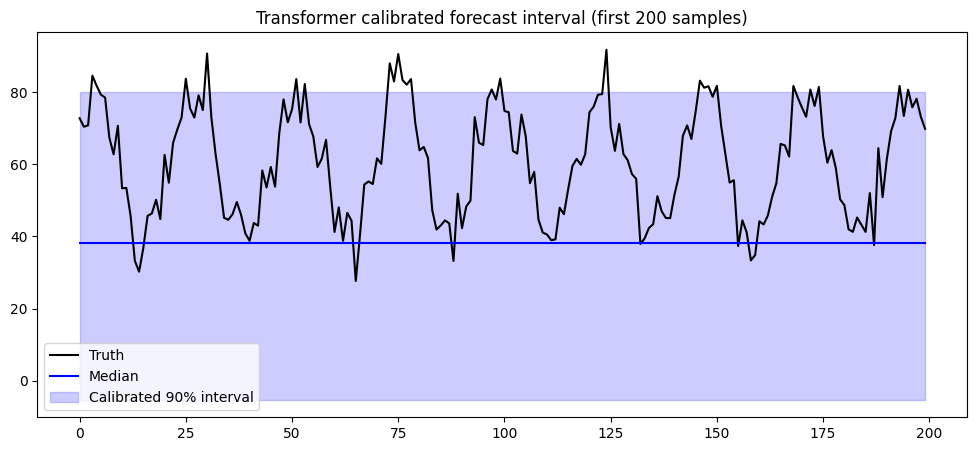

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test_true[:200], label="Truth", color="black")
plt.plot(pred_med_test[:200], label="Median", color="blue")
plt.fill_between(range(200), lo_cal[:200], hi_cal[:200], color="blue", alpha=0.2, label="Calibrated 90% interval")
plt.legend(); plt.title("Transformer calibrated forecast interval (first 200 samples)")
plt.show()
